In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [2]:
DIR=os.getcwd()
PATH=DIR+'/../data/raw/Webull_Orders_Records.csv'
DATA_PLATFORM=pd.read_csv(PATH)
DATA_PLATFORM.head(5)

,Name,Symbol,Side,Status,Filled,Total Qty,Price,Avg Price,Time-in-Force,Placed Time,Filled Time
0,Intel Corp,INTC,Sell,Filled,10.0,10.0,104.9550000000,104.955,DAY,09/08/2026 14:40:11 EDT,09/08/2026 14:40:11 EDT
1,Intel Corp,INTC,Sell,Filled,6.7,6.7,@87.4600000000,87.460,DAY,08/24/2026 11:52:33 EDT,08/24/2026 11:52:34 EDT
2,Intel Corp,INTC,Sell,Cancelled,0.0,6.7,@87.68,NaN,DAY,08/24/2026 11:50:46 EDT,NaN
3,Intel Corp,INTC,Sell,Cancelled,0.0,6.7,@87.71,NaN,DAY,08/24/2026 11:38:44 EDT,NaN
4,Intel Corp,INTC,Sell,Cancelled,0.0,6.7,@86.91,NaN,DAY,08/24/2026 11:31:46 EDT,NaN


In [3]:

import datetime as dt
DATA_PLATFORM=pd.read_csv(PATH)
DATA_PLATFORM['Price']=pd.to_numeric(DATA_PLATFORM['Price'].apply(lambda x:x.replace('@','')),errors='coerce')
DATA_PLATFORM['Placed Time']=pd.to_datetime(DATA_PLATFORM['Placed Time'],exact=False,errors='coerce')
DATA_PLATFORM['date']=DATA_PLATFORM['Placed Time'].dt.date
DATA_PLATFORM['hour']=DATA_PLATFORM['Placed Time']
DATA_PLATFORM.groupby('date')

/var/folders/vv/1tq0kp8922s3nrfrcgp3c2j80000gn/T/ipykernel_34439/2698888088.py:4: FutureWarning: Parsed string "09/08/2026 14:40:11 EDT" included an un-recognized timezone "EDT". Dropping unrecognized timezones is deprecated; in a future version this will raise. Instead pass the string without the timezone, then use .tz_localize to convert to a recognized timezone.
  DATA_PLATFORM['Placed Time']=pd.to_datetime(DATA_PLATFORM['Placed Time'],exact=False,errors='coerce')


Text(0, 0.5, 'Number of trades')

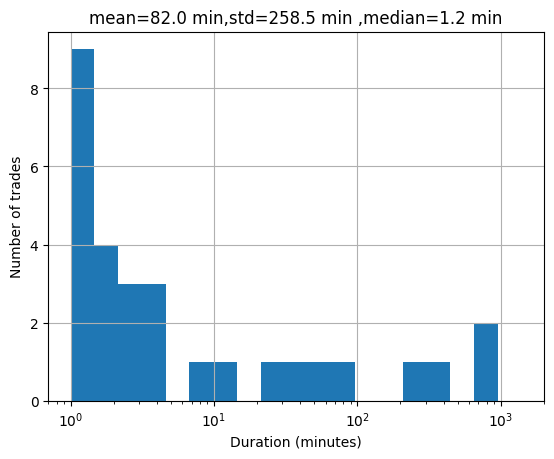

In [4]:
filled=DATA_PLATFORM[DATA_PLATFORM['Status']=='Filled']
buys=filled[filled['Side']=='Buy']
sells=filled[filled['Side']=='Sell']
trades=buys.merge(sells,on='date',suffixes=['_buy','_sell'])
trades['duration (minutes)']=(trades['hour_sell']-trades['hour_buy']).dt.seconds/60
trades['Total Qty difference']=trades['Total Qty_sell']-trades['Total Qty_buy']
trades['similar_cuant']=trades['Total Qty difference']<0.1
bins=np.geomspace(1,1400,20)
trades['duration (minutes)'].hist(bins=bins)
plt.xscale('log')
# plt.yscale('log')
mean=trades['duration (minutes)'].mean()
std=trades['duration (minutes)'].std()
median = trades['duration (minutes)'].median()
plt.title(f'mean={mean:.1f} min,std={std:.1f} min ,median={median:.1f} min')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of trades')

# Data with a trade duration less than 10 minutes

/var/folders/vv/1tq0kp8922s3nrfrcgp3c2j80000gn/T/ipykernel_34439/898932949.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  First_group['duration (seconds)']=60*First_group['duration (minutes)']


Text(0, 0.5, 'Number of trades')

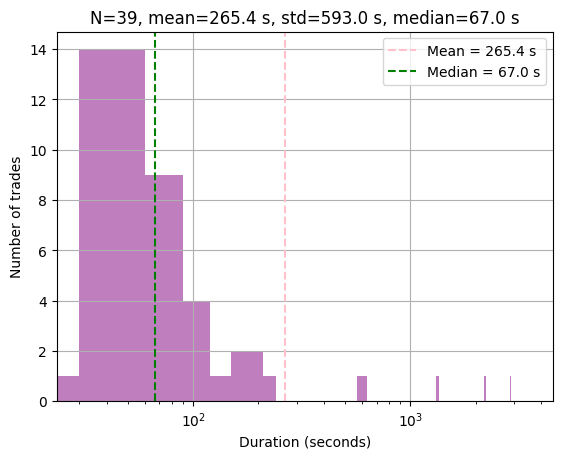

In [5]:
First_group=trades[trades['duration (minutes)']<=60]
First_group['duration (seconds)']=60*First_group['duration (minutes)']
bins=np.arange(0,3600,30)
First_group['duration (seconds)'].hist(bins=bins,color='purple',alpha=0.5)
mean=First_group['duration (seconds)'].mean()
std=First_group['duration (seconds)'].std()
median = First_group['duration (seconds)'].median()
n_trades = len(First_group)
plt.title(f'N={n_trades}, mean={mean:.1f} s, std={std:.1f} s, median={median:.1f} s')
plt.axvline(mean, linestyle='--', label=f'Mean = {mean:.1f} s',color='pink')
plt.axvline(median, linestyle='--', label=f'Median = {median:.1f} s',color='green')
plt.xscale('log')
plt.legend()
plt.xlabel('Duration (seconds)')
plt.ylabel('Number of trades')

# Data with a trade duration greater than 60 minutes

Text(0, 0.5, 'Number of trades')

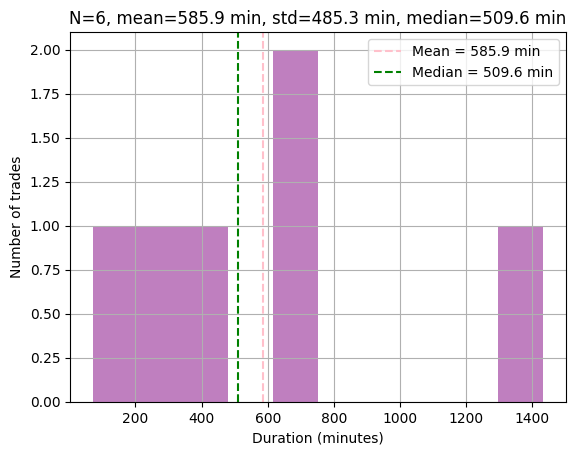

In [6]:
Third_group=trades[trades['duration (minutes)']>60]
Third_group['duration (minutes)'].hist(color='purple',alpha=0.5)
mean=Third_group['duration (minutes)'].mean()
std=Third_group['duration (minutes)'].std()
median = Third_group['duration (minutes)'].median()
n_trades = len(Third_group)
plt.title(f'N={n_trades}, mean={mean:.1f} min, std={std:.1f} min, median={median:.1f} min')
plt.axvline(mean, linestyle='--', label=f'Mean = {mean:.1f} min',color='pink')
plt.axvline(median, linestyle='--', label=f'Median = {median:.1f} min',color='green')
plt.legend()
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of trades')

# Change in Price

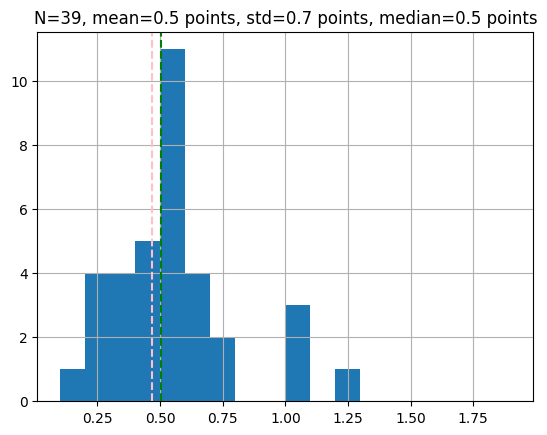

In [9]:
changes_per_share=First_group['Price_sell']-First_group['Price_buy']
bins=np.arange(0.1,2,0.1)
changes_per_share.hist(bins=bins)
mean=changes_per_share.mean()
std=changes_per_share.std()
median = changes_per_share.median()
n_trades = len(changes_per_share)
plt.title(f'N={n_trades}, mean={mean:.1f} points, std={std:.1f} points, median={median:.1f} points')
plt.axvline(mean, linestyle='--', label=f'Mean = {mean:.1f} USD',color='pink')
plt.axvline(median, linestyle='--', label=f'Median = {median:.1f} USD',color='green')

# Duration vs Change in Price

(0.0, 10.0)

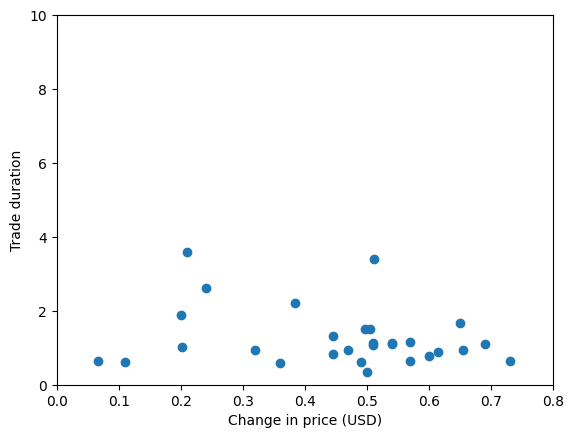

In [8]:
plt.scatter(changes_per_share,First_group['duration (minutes)'])
plt.xlabel('Change in price (USD)')
plt.ylabel('Trade duration')
plt.xlim(0,0.8)
plt.ylim(0,10)


Trade duration does not appear to determine the realized price change, which is consistent with the use of a relatively fixed profit target.